# Task 1: Exploratory Data Analysis (EDA)


- Libraries Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
import math

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


from sklearn.model_selection import GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



df = pd.read_csv("car_price.csv")

- Dimensions of the data & the first 15 rows.

In [2]:
print(f'rows and columns number: {df.shape}')
df.head(15)

rows and columns number: (72435, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi
5,A1,2016.0,13900.0,Automatic,32260.0,Petrol,30.0,58.9,1.4,audi
6,A6,2016.0,13250.0,Automatic,76788.0,Diesel,30.0,61.4,2.0,audi
7,A4,2016.0,11750.0,NaN,75185.0,Diesel,20.0,70.6,2.0,audi
8,A3,2015.0,10200.0,Manual,46112.0,Petrol,20.0,60.1,1.4,audi
9,A1,2016.0,12000.0,Manual,22451.0,NaN,30.0,55.4,1.4,audi


- knowing the categorical and numerical features.

In [3]:
df.info()
print("Numerical Features:")
print(df.select_dtypes(include=np.number).columns)
print("\nCategorical Features:")
print(df.select_dtypes(exclude=np.number).columns)

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  str    
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  str    
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  str    
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  str    
dtypes: float64(6), str(4)
memory usage: 5.5 MB
Numerical Features:
Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='str')

Categorical Features:
Index(['model', 'transmission', 'fuelType', 'Make'], dtype='str')


- Description of data


In [4]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


- determining the number of missing values in each feature.

In [5]:
df.isnull().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

- Lets plot the histogram of the price to show the distribution.
- Rice Rule: Bins = 2 * cubic root(n), this is generally better for larger datasets.

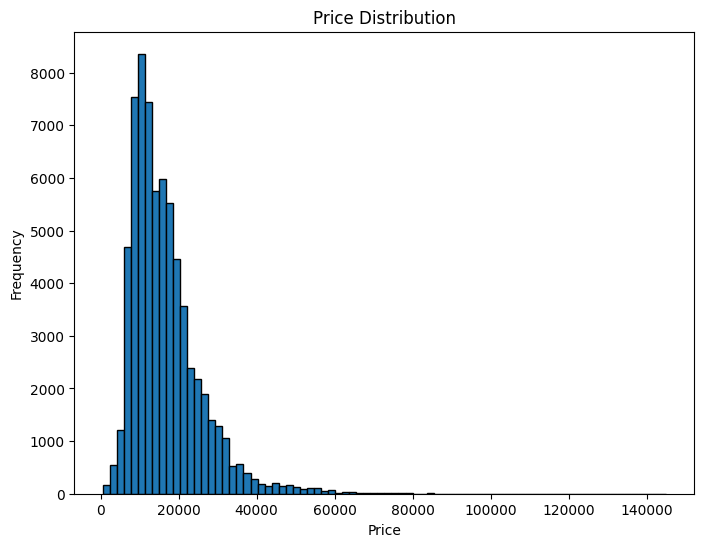

In [6]:
plt.figure(figsize=(8,6))
plt.hist(
    df['price'],
    bins=80,
    edgecolor='black'
)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()

- it shows that it is right skewed!

- Compute correlation matrix for numerical features only, creating a heatmap to visualize relationships between those numerical features.

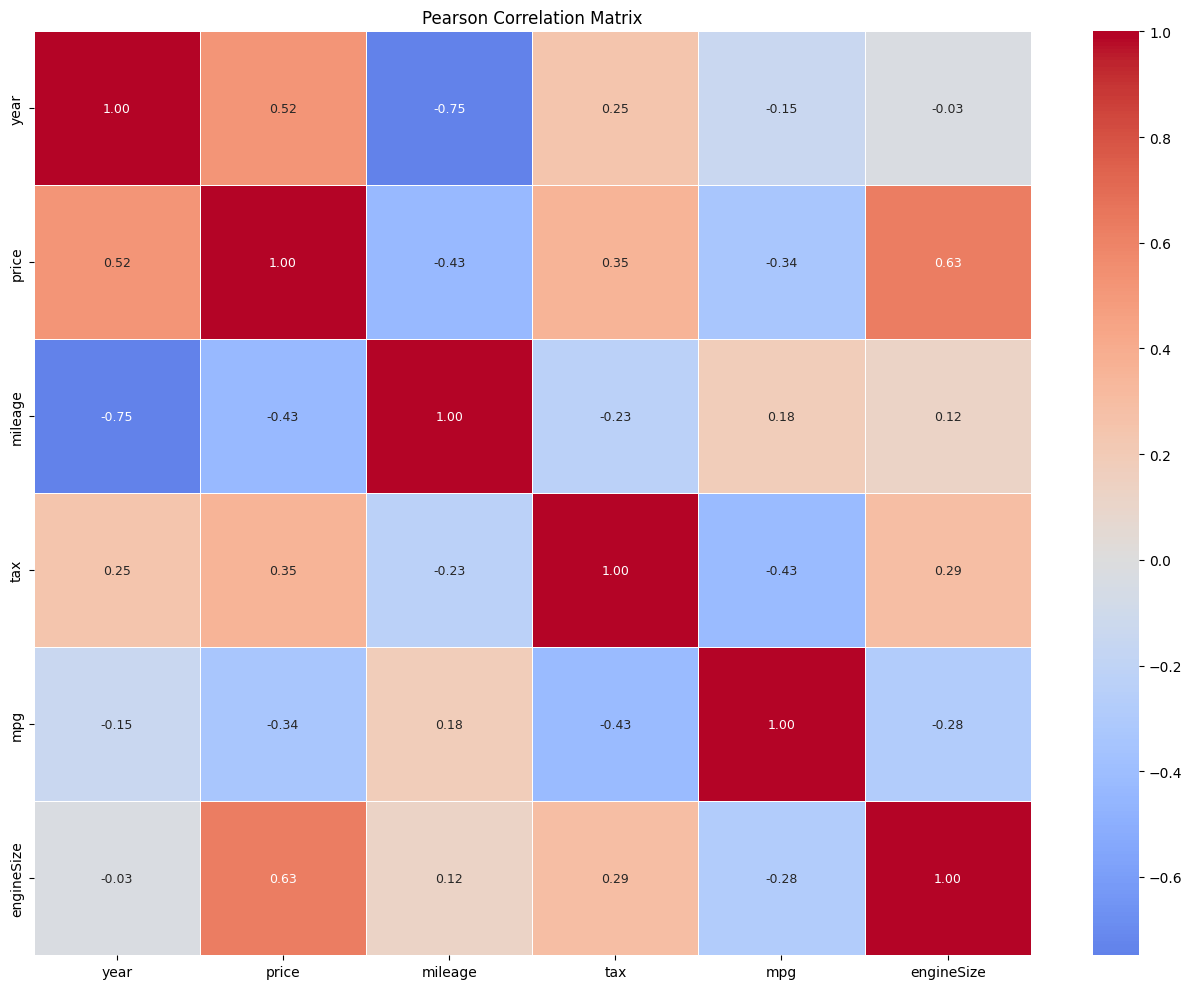

Top features related to Price:
price         1.000000
engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64


In [7]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr,
    annot=True,          # display correlation values
    fmt='.2f',           # show values with 2 decimal places
    cmap='coolwarm',     # color map for positive and negative correlation
    center=0,            # center colors around zero
    linewidths=0.4,
    annot_kws={'size': 9}
)

plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

# 1.00 (Dark Red): A perfect match. If one icreases, the other increase exactly the same way.
# -1.00 (Dark Blue): Perfect opposites. If one increases, the other decreases.
# 0.00 (White/Light): No connection at all. Changing one doesn't tell us anything about the other.

# the features that are mostly related to the price
print("Top features related to Price:")
print(corr['price'].sort_values(ascending=False))

# Task 2: Data Preprocessing

## 1) Train / test Split
- Also drop missing values from the price column to avoid errors, cause the price attribute is the targeted attribute to predict.

In [8]:
# Drop Na for price column
df = df.dropna(subset=['price'])

# Remove duplicates
df = df.drop_duplicates()

# Define features and target variable
X = df.drop(columns='price')
y = df['price']


x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print(f'Train: {x_train.shape}  |  Test: {x_test.shape}')

Train: (54769, 9)  |  Test: (13693, 9)


## 2) Handle missing values

- According to the number of missing values displayed in task1, to deal with the missing values we got, we can fill the missing values with means/medians in the float datatype columns, except the "year" column, which can be filled using KNN. Additionally, the problem of null values in string datatype columns can be solved using the mode function.

In [9]:
# Numerical Columns (Median)
num_cols = ['mileage', 'tax', "mpg", 'engineSize']

for col in num_cols:
    median_val = x_train[col].median()
    x_train[col] = x_train[col].fillna(median_val)
    x_test[col] = x_test[col].fillna(median_val)

# Categories Columns (Mod)
cat_cols = ['model', 'transmission', 'fuelType', 'Make']

for col in cat_cols:
    mode_val = x_train[col].mode()[0]
    x_train[col] = x_train[col].fillna(mode_val)
    x_test[col] = x_test[col].fillna(mode_val)

# Year Column (KNN)
year_cols = ['year']
k = max(1, int(math.sqrt(len(df))))

imputer = KNNImputer(n_neighbors=k)

x_train[year_cols] = imputer.fit_transform(x_train[year_cols])
x_test[year_cols] = imputer.transform(x_test[year_cols])

## 3) Encode categorical columns

- We use One-Hot Encoding, cause we have nominal data, not ordinal relationships on "model", "transmission", "fuelType", and "Make" Columns.

In [10]:
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

train_enc = enc.fit_transform(x_train[cat_cols])
test_enc = enc.transform(x_test[cat_cols])

train_enc_df = pd.DataFrame(
    train_enc,
    columns=enc.get_feature_names_out(cat_cols),
    index=x_train.index
)

test_enc_df = pd.DataFrame(
    test_enc,
    columns=enc.get_feature_names_out(cat_cols),
    index=x_test.index
)

x_train = pd.concat([x_train.drop(columns=cat_cols), train_enc_df], axis=1)
x_test = pd.concat([x_test.drop(columns=cat_cols), test_enc_df], axis=1)


## 4) Detect and handle outliers
- to be able to use minmax scaling without errors or wrong values.

IQR outliers in price: 2114


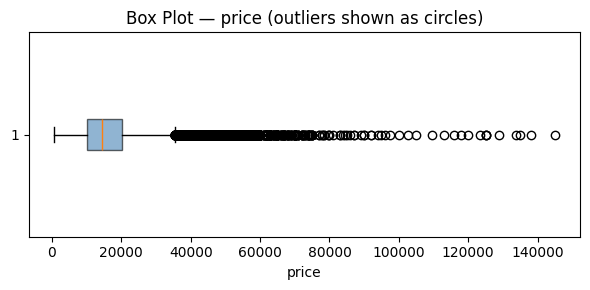

Training rows remaining after trimming: 52655


In [11]:
# --- IQR method on y_train ---
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# Detect outliers
outliers_iqr = y_train[(y_train < lower) | (y_train > upper)]

print(f'IQR outliers in price: {len(outliers_iqr)}')


# Visualization
plt.figure(figsize=(6, 3))

plt.boxplot(
    y_train,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)

plt.title('Box Plot — price (outliers shown as circles)')
plt.xlabel('price')
plt.tight_layout()
plt.show()

x_train = x_train.drop(index=outliers_iqr.index)
y_train = y_train.drop(index=outliers_iqr.index)
print(f"Training rows remaining after trimming: {len(y_train)}")

## 5) Scale numerical features
- Scaling the numerical data to avoid being biased by some features.
- We can use Standard Scaling and MinMax Scaling, especially after removing the outliers, which gives close results, but using MinMax Scaling is better, giving a range in [0,1], which improves KNN performance, because it is distance-based.

In [12]:
# Save copies before scaling
x_train_before_scaling = x_train.copy()
x_test_before_scaling = x_test.copy()

scaler = MinMaxScaler()

# Fit on train only
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])

# Transform test
x_test[num_cols] = scaler.transform(x_test[num_cols])

# Task 3: Create Two Target Variables


## 1) The Regression Target Variable

In [13]:
y_reg = df['price']
print(y_reg.head())

0    12500.0
1    16500.0
2    11000.0
3    16800.0
4    17300.0
Name: price, dtype: float64


## 2) The Classification Target Variable

- Classification target using equal-frequency binning
- we will identify the thresholds based on the distribution (Histogram and the describe method)

In [14]:
print(df['price'].describe())

count     68462.000000
mean      16568.548275
std        9298.433764
min         495.000000
25%       10150.000000
50%       14495.000000
75%       20269.750000
max      145000.000000
Name: price, dtype: float64


- We used pd.qcut() to divide the continuous price feature into three equal-frequency categories.
- Since the price distribution is right-skewed
- qcut is more suitable than cut because it creates balanced classes, which improves KNN performance

In [15]:
# Create classification target using equal-frequency binning on training set only to avoid data leakage
y_train_cat, bin_edges = pd.qcut(
    y_train,
    q=3,
    labels=['Cheap', 'Moderate', 'Expensive'],
    retbins=True
)

# Apply the same boundaries to the test set
y_test_cat = pd.cut(
    y_test,
    bins=[-np.inf, *bin_edges[1:-1], np.inf],
    labels=['Cheap', 'Moderate', 'Expensive']
)

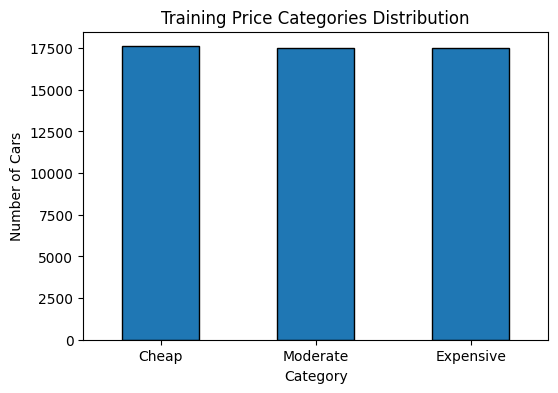

In [16]:
# Plotting the training price categories distribution
plt.figure(figsize=(6,4))
y_train_cat.value_counts().sort_index().plot(
    kind='bar',
    edgecolor='black'
)

plt.title("Training Price Categories Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Cars")
plt.xticks(rotation=0)
plt.show()

In [17]:
# Display the number of cars in each category
print("\n=== Number of Cars in Each Category ===")
print("\nTraining Set (80%):")
print(y_train_cat.value_counts().sort_index())

print("\nTest Set (20%):")
print(y_test_cat.value_counts().sort_index())

# Display bin boundaries
print("\nPrice Boundaries:")
print(bin_edges)


=== Number of Cars in Each Category ===

Training Set (80%):
price
Cheap        17605
Moderate     17521
Expensive    17529
Name: count, dtype: int64

Test Set (20%):
price
Cheap        4458
Moderate     4368
Expensive    4867
Name: count, dtype: int64

Price Boundaries:
[  495. 11250. 17498. 35436.]


# Task 4: Model 1 - Linear Regression

- Using multivariable liner regression to predict the price for a given car according to its features.

R2 Score: 0.7765
Root Mean Squared Error: 4339.04


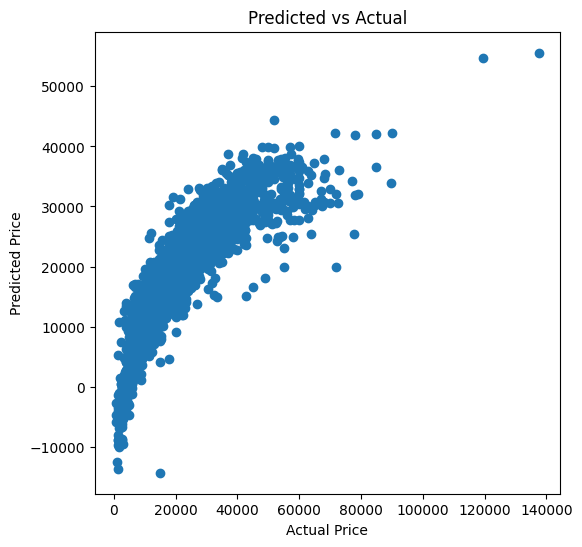

In [18]:
multi_model = LinearRegression()
multi_model.fit(x_train, y_train)

y_pred_multi = multi_model.predict(x_test)

# Evaluation
print(f"R2 Score: {r2_score(y_test, y_pred_multi):.4f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred_multi)):.2f}")

# Visualization: Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_multi)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.show()


# Task 5: Model 2: KNN Classification

Try different k values and distance metrics to find the best combination 

In [19]:
param_grid = {
    'n_neighbors': range(3, 31, 2),
    'metric': ['euclidean', 'manhattan']
}

# Initialize KNN model
knn = KNeighborsClassifier()

# Use 5-fold cross-validation for more reliable evaluation
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Run Grid Search to test all parameter combinations and pick the best one
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1
)

In [20]:
# Train the model on scaled training data (important for KNN)
grid_search.fit(x_train, y_train_cat)

# Show best parameters and corresponding accuracy
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5}
Best CV Accuracy: 0.8650


In [21]:
# Use the best model to make predictions on test data
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(x_test)

# Evaluate model performance using accuracy and detailed metrics
print(f"Accuracy Score: {accuracy_score(y_test_cat, y_pred):.4f}")
print(classification_report(y_test_cat, y_pred))

Accuracy Score: 0.8742
              precision    recall  f1-score   support

       Cheap       0.91      0.90      0.90      4458
   Expensive       0.91      0.91      0.91      4867
    Moderate       0.80      0.81      0.81      4368

    accuracy                           0.87     13693
   macro avg       0.87      0.87      0.87     13693
weighted avg       0.87      0.87      0.87     13693



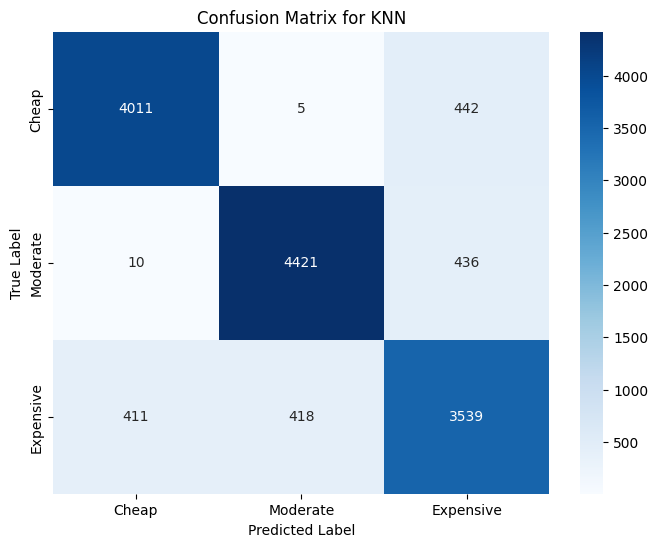

In [22]:
# Plot confusion matrix to see prediction errors between classes
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_matrix(y_test_cat, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Cheap', 'Moderate', 'Expensive'],
    yticklabels=['Cheap', 'Moderate', 'Expensive']
)

plt.title('Confusion Matrix for KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## the Confusion Matrix
- The confusion matrix shows how well the model sorts cars into three groups: Cheap, Moderate, and Expensive.

### Strong Accuracy at the Extremes (The Diagonal)
- The model is very good at identifying Cheap and Expensive cars. This is because these two groups have very clear differences. For example, expensive cars almost always have larger engines and lower mileage, while cheap cars show the opposite. The model recognizes these signatures easily.

### Overlap at the Borders (Boundary Errors)
- Most mistakes happen between categories that are next to each other (for example, calling a Moderate car Expensive). This happens because cars priced right at the cutoff line share almost identical features. It is mathematically difficult for the model to draw a perfect line when two cars are only a few dollars apart in price.

### Financial Impact (Buyer's Perspective)
- Errors in the model result in real-world risks or opportunities:
    False Positive (Overvaluation): The model labels a car as Expensive when it is actually Moderate. This is a Type I Error. For a buyer, this is a risk because they might end up overpaying for a mid-range car.
    False Negative (The Bargain): The model labels an Expensive car as Moderate. This is a Type II Error. For a buyer, this is a bargain, it identifies a high-value car that is priced lower than it should be.

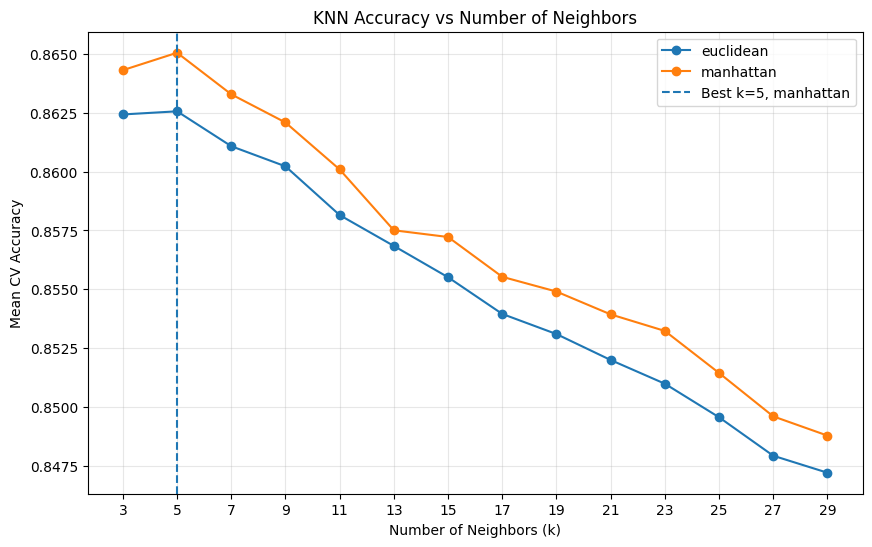

In [23]:
# Analyze how k and distance metric affect accuracy
results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 6))

for metric in ['euclidean', 'manhattan']:
    subset = results[results['param_metric'] == metric]

    plt.plot(
        subset['param_n_neighbors'],
        subset['mean_test_score'],
        marker='o',
        label=metric
    )

# Highlight the best k value
best_k = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']

plt.axvline(
    best_k,
    linestyle='--',
    label=f'Best k={best_k}, {best_metric}'
)

plt.title('KNN Accuracy vs Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(np.arange(3, 31, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Task 6: Analysis and Discussion

### Model Comparison

1) Which model performed better ?
- In the Regression context (Linear Regression): "Better" means accurately predicting the exact, continuous price of the vehicle. It is evaluated here using the R2 score (77.65%), which means the model successfully captures and explains roughly 78% of the variance in the actual car prices based on the input features.

- In the Classification context (KNN): "Better" means successfully sorting a car into the correct broad price category (cheap, moderate, expensive). It is evaluated here using Accuracy (87.42%), meaning the model placed the car into the correct category 87% of the time.

- While the KNN's 87.42% Accuracy appears numerically higher than the Linear Regression's 77.65% R2 score, a direct comparison is misleading because they are taking tests of different difficulties. The Linear Regression model is the better, more useful model. The KNN classifier achieves a higher score by grouping continuous prices into wide categories, giving it a massive, forgiving margin of error. It achieves this high accuracy precisely by sacrificing granular detail. The Linear Regression model takes on the much harder task of predicting exact prices and still performs strongly, preserving valuable and precise information about the vehicle's true market value.

2) Is classification easier than regression on this dataset ?
- Basically, classification is easier for the model because it doesn't have to guess the exact number; it just has to land in the right category. This gives it a huge margin for error. But getting a high accuracy score this way is kind of an illusion. By putting different prices together into one group, you lose a lot of detail. The model ends up treating a car at the very bottom of a category exactly the same as one at the top, making the final answer much less precise than regression.

3) Does converting price into categories lose important information?
- Yes, converting the exact car price into categories leads to a loss of important information.

- By grouping prices, the model becomes blind to differences within the same category. It ends up treating a $10k car and a $19k car as the exact same thing.

- Categorization forces rigid, "crisp" cutoffs. Two cars priced at $9,995 and $10,005 are virtually identical in reality, but a crisp $10k boundary forces the model to treat them as completely different classes. It assumes a sudden jump in meaning, rather than a gradual (or "fuzzy") real-world transition.

- The model forgets "how far off" it is. Guessing a car is "Cheap" when it is actually "Moderate" is penalized the exact same way as guessing "Cheap" when it is actually "Expensive."

### Sensitivity Analysis

*1) What happens if you remove the most correlated feature ?*

In [24]:
# Remove the most correlated feature
x_train_no_engine = x_train.drop(columns=['engineSize'])
x_test_no_engine = x_test.drop(columns=['engineSize'])

# Train regression model without Engine
model_no_engine = LinearRegression()
model_no_engine.fit(x_train_no_engine, y_train)

# Predict
y_pred_no_engine = model_no_engine.predict(x_test_no_engine)

# Evaluation
print("Original R Squared:",
      r2_score(y_test, y_pred_multi))

print("R Squared without Engine Size feature:",
      r2_score(y_test, y_pred_no_engine))

print("Original Root Mean Squared Error:",
      np.sqrt(mean_squared_error(y_test, y_pred_multi)))

print("Root Mean Squared Error without Engine Size feature:",
      np.sqrt(mean_squared_error(y_test, y_pred_no_engine)))

Original R Squared: 0.7765396362701164
R Squared without Engine Size feature: 0.7459945854446957
Original Root Mean Squared Error: 4339.043531107562
Root Mean Squared Error without Engine Size feature: 4626.102420905724


- Removing the most correlated feature (the Engine Size feature) caused a minor drop in performance. The R2 score decreased by only ~3% (77.65% to 74.60%), and the Root Mean Squared Error increased by just ~287. While 'Engine' was the strongest individual predictor, the remaining features contained enough overlapping information to successfully compensate for its absence, preventing major error in the model's predictive power.

In [25]:
# Remove the most correlated feature
x_train_knn = x_train.drop(columns=['engineSize'])
x_test_knn = x_test.drop(columns=['engineSize'])

knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan')

knn.fit(x_train_knn, y_train_cat)

y_pred_knn = knn.predict(x_test_knn)


print("Accuracy with most correlated feature:",
      accuracy_score(y_test_cat, y_pred))

print("Accuracy without most correlated feature",
      accuracy_score(y_test_cat, y_pred_knn))

print("Performance drop:",
      accuracy_score(y_test_cat, y_pred) -accuracy_score(y_test_cat, y_pred_knn))

Accuracy with most correlated feature: 0.8742423135908859
Accuracy without most correlated feature 0.868253852333309
Performance drop: 0.005988461257576905


Removing the most correlated feature affects Linear Regression directly due to its linear dependency assumption, while in KNN it indirectly affects performance by changing the distance structure between data points in the feature space.The model’s accuracy decreased by a negligible 0.59% (from 87.42% to 86.83%), confirming that the performance remained stable. This minimal drop is due to feature redundancy: although engineSize is strongly related to price, other strong features like mileage and year carry similar information.This proves the KNN model is robust and does not rely on a single variable to maintain accurate price classification.

*2) Try running KNN without scaling*

In [26]:
# KNN without scaling
grid_search_no_scale = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_no_scale.fit(
    x_train_before_scaling,
    y_train_cat
)

y_pred_no_scale = grid_search_no_scale.best_estimator_.predict(
    x_test_before_scaling
)

acc_no_scale = accuracy_score(y_test_cat, y_pred_no_scale)

print("Accuracy with scaling:",
      accuracy_score(y_test_cat, y_pred))

print("Accuracy without scaling:",
      acc_no_scale)

print("Performance drop:",
      accuracy_score(y_test_cat, y_pred) - acc_no_scale)

Accuracy with scaling: 0.8742423135908859
Accuracy without scaling: 0.6035930767545461
Performance drop: 0.2706492368363398


- Removing feature scaling resulted in a massive 27.1% drop in accuracy. This happens because KNN is a distance-based algorithm. In unscaled data, features with naturally large numbers (like mileage) completely overpower features with smaller numbers (like engine size) during the distance calculation. The 60.4% accuracy shows that without scaling, the model becomes blind to the smaller-scale features, leading to highly inaccurate predictions.

*3) Try a different threshold for your price categories*

In [27]:
y_train_alt, alt_bins = pd.qcut(
    y_train,
    q=[0, 0.4, 0.7, 1],
    labels=['Cheap', 'Moderate', 'Expensive'],
    retbins=True
)

y_test_alt = pd.cut(
    y_test,
    bins=[-np.inf, *alt_bins[1:-1], np.inf],
    labels=['Cheap', 'Moderate', 'Expensive']
)

knn_alt = KNeighborsClassifier(
    n_neighbors=best_k,
    metric=best_metric
)

knn_alt.fit(x_train, y_train_alt)

y_pred_alt = knn_alt.predict(x_test)

alt_accuracy = accuracy_score(y_test_alt, y_pred_alt)

print("Original Accuracy:",
      accuracy_score(y_test_cat, y_pred))

print("New Threshold Accuracy:",
      alt_accuracy)

print("Difference:",
      alt_accuracy - accuracy_score(y_test_cat, y_pred))

Original Accuracy: 0.8742423135908859
New Threshold Accuracy: 0.8708099028700796
Difference: -0.003432410720806245


- Modifying the price category thresholds led to a insignificant performance drop of just 0.34%. This proves that our original high accuracy wasn't just a fluke based on lucky boundary placement; the model is stable, robust, and consistently recognizes the core patterns in the data regardless of minor changes to the category definitions.

# Task 7: Required Visualizations

1) The Histogram ( In Task 1 EDA)
it helped us understand the distribution of car prices in the dataset.

​The distribution is clearly right-skewed, showing that most cars are concentrated in the lower to moderate price range, while only a few cars have very high prices.

​This observation was useful in Task 2, as it highlighted the presence of high-price outliers, which were later handled using the IQR method.

​It also supported our decision in Task 3 to divide prices into Cheap, Moderate, and Expensive categories using quantile-based splitting, since the data is not normally distributed.


2) correlation heatmap the (In Task 1 EDA)
The Heatmap served as a strategic roadmap for our feature selection, revealing how numerical variables interact with the car's price.

​The most significant finding was the strong positive correlation (0.63) between engine size and price, identifying it as the primary driver for our models. This was later validated in Task 6.2 (Sensitivity Analysis), where removing this feature caused a performance drop, confirming its predictive power while proving that the model still relies on a combination of other features.

​On the other hand, mileage showed a notable negative correlation (-0.43), aligning with the logical expectation that higher usage reduces a car's market value.

​Ultimately, this analysis provided the necessary 'feature intelligence' to refine both our Linear Regression (Task 4) and KNN Classification(Task 5), ensuring that our models are built on the most impactful data points.

3) Predicted vs. Actual scatter plot( in Task 4 ( Model 1: Linear Regression) )
This evaluates the performance of the Linear Regression model.

​The x-axis represents the actual car prices, while the y-axis represents the predicted prices generated by the model.

​From the plot, most points follow a clear increasing trend, which indicates that the model is able to capture the general relationship between the features and car price.

​However, the spread of points around the trend shows the presence of prediction errors, especially for higher price values. This is consistent with the obtained R Squared score of 0.7765, which means that the model explains approximately 77.65% of the variance in car prices.

​In addition, the RMSE value of 4339.04 indicates that the model’s predictions differ from the actual prices by an average of about 4339 units.

4) confusion matrix ( in Task 5 ( Model 2: KNN Classification ) )

​It evaluates the performance of the KNN classification model across the three price categories defined in Task 3.The rows represent the actual categories, while the columns represent the predicted categories.

​The high diagonal values indicate strong predictive performance, with the model correctly classifying
4011 Cheap cars,
4421 Moderate cars,
and 3539 Expensive cars.

​The off-diagonal values represent misclassifications, which mostly occur between neighboring categories.This is expected because cars near the category thresholds may share similar features.

​Overall, this visualization confirms the effectiveness and stability of the KNN model in predicting price categories .

Additional plots :

1) Box Plot (Task 2: Preprocessing )

to identify outliers in the target variable (price).

​The box represents the interquartile range, while the line inside the box shows the median price.
​The circles outside the whiskers represent outliers, which are cars with unusually high prices.
​This visualization was important for applying the IQR method to detect extreme values before training the models. Handling these outliers helped reduce their impact on the Linear Regression model and improved the overall data quality.


2) bar chart ( distribution of the training data )
three defined price categories: Cheap, Moderate, and Expensive.

​Class Balance: The dataset exhibits a uniform distribution, with each category comprising approximately 17,500 instances. This confirms that the classes are perfectly balanced.

​Methodology: This equilibrium was achieved through quantile-based splitting (qcut), which partitioned the target variable into three equal-frequency groups based on the price values.

​Impact on Modeling: Maintaining balanced classes is a critical step for Task 5 (KNN Classification). It ensures that the model does not develop a bias toward a majority class, thereby enhancing the reliability of the distance-based neighbor selection.

​Performance Reliability: This balanced split is a primary factor behind the high stability and performance observed later in the confusion matrix and accuracy scores, as the model is equally trained to recognize all price segments.

3) plot KNN Accuracy vs Number of Neighbors ( from Task 5)
It illustrates the Grid Search optimization process showing how the KNN model accuracy changes with different values of k and distance metrics.

​The results clearly identify k = 5 with Manhattan distance as the optimal configuration, achieving the highest cross-validation accuracy of approximately 86.5%.

​We also observe a gradual decline in accuracy as k increases beyond 5. This is expected in KNN, as larger values of k may lead to over-smoothing,
causing the model to lose important local patterns that distinguish the price categories.

​In addition, Manhattan distance consistently performed slightly better than Euclidean distance, which justifies its selection as the final metric for the model.